# 🚗 Motion Deblurring of License Plate Images

> **Computer Vision Final Project**; Group **BufferOverflow** (Methqphore)

This notebook implements a complete pipeline for:
1. **Simulating** motion blur on license plate images using parametric PSF kernels
2. **Restoring** degraded images via Inverse Filtering and Wiener Filtering (frequency domain)
3. **Enhancing** restored images with CLAHE, Unsharp Masking, and Adaptive Binarization
4. **Evaluating** restoration quality using PSNR and SSIM metrics
5. **Visualizing** results with comparison panels and statistical charts

---

## 1. Setup & Imports

We use **OpenCV** for image processing, **NumPy** for array operations and FFT,
**scikit-image** for quality metrics, **pandas** for tabular results, and **matplotlib** for visualization.

In [4]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Display settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print('All imports successful.')

All imports successful.


## 2. Configuration & Folder Setup

Define all paths and parameters in one place for easy modification.

In [5]:
# ── Paths ──────────────────────────────────────────────────
INPUT_FOLDER             = '../data/original'
BLURRED_FOLDER           = '../data/blurred'
KERNEL_FOLDER            = '../data/kernels'
RESTORED_INVERSE_FOLDER  = '../data/restored_inverse'
RESTORED_WIENER_FOLDER   = '../data/restored_wiener'
ENHANCED_FOLDER          = '../data/enhanced'
THRESHOLDED_FOLDER       = '../data/thresholded'
COMPARISON_FOLDER        = '../data/comparisons'
ENHANCE_COMPARISON_FOLDER = '../data/enhanced_comparisons'
METRICS_FOLDER           = '../data/metrics'

# ── Image dimensions ───────────────────────────────────────
IMG_WIDTH  = 256
IMG_HEIGHT = 128

# ── Blur parameters ────────────────────────────────────────
BLUR_LENGTHS = [5, 10, 15, 20]
BLUR_ANGLES  = [0, 15, 30, 45]

# ── Create output directories ──────────────────────────────
for folder in [
    BLURRED_FOLDER, KERNEL_FOLDER,
    RESTORED_INVERSE_FOLDER, RESTORED_WIENER_FOLDER,
    ENHANCED_FOLDER, THRESHOLDED_FOLDER,
    COMPARISON_FOLDER, ENHANCE_COMPARISON_FOLDER,
    METRICS_FOLDER
]:
    os.makedirs(folder, exist_ok=True)

print('All output directories created.')

All output directories created.


## 3. Preprocessing & Motion Blur Simulation

### Theory

Motion blur is modeled as a **convolution** of the sharp image $f(x,y)$ with a
**Point Spread Function (PSF)** $h(x,y)$:

$$g(x,y) = f(x,y) * h(x,y) + n(x,y)$$

where $g$ is the blurred observation and $n$ is additive noise.

The PSF for linear motion of length $L$ at angle $\\theta$ is a thin line rotated
about its center. We normalize it so $\\sum h = 1$.

### Steps
1. Load each image → convert to **grayscale** → resize to 256×128
2. Create parametric motion blur kernels (4 lengths × 4 angles = 16 variants)
3. Apply each kernel via `cv2.filter2D` (spatial-domain convolution)

In [6]:
def preprocess_image(image, width=IMG_WIDTH, height=IMG_HEIGHT):
    """Convert BGR image to grayscale and resize to fixed resolution."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (width, height))
    return resized


def motion_blur_kernel(length=15, angle=0):
    """
    Create a 2D motion blur kernel with given length and angle.

    The kernel is a horizontal line of 1s, rotated by the specified angle,
    then normalized so the sum equals 1.
    """
    kernel = np.zeros((length, length), dtype=np.float32)
    kernel[length // 2, :] = 1.0

    # Rotate around center
    center = (length / 2 - 0.5, length / 2 - 0.5)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_kernel = cv2.warpAffine(kernel, rotation_matrix, (length, length))

    # Normalize
    kernel_sum = rotated_kernel.sum()
    if kernel_sum != 0:
        rotated_kernel /= kernel_sum

    return rotated_kernel


def apply_motion_blur(image, kernel):
    """Apply convolution using the motion blur kernel."""
    return cv2.filter2D(image, -1, kernel)


def save_kernel_visualization(kernel, save_path):
    """Save a normalized visualization of the kernel as an image."""
    vis = cv2.normalize(kernel.copy(), None, 0, 255, cv2.NORM_MINMAX)
    cv2.imwrite(save_path, vis.astype(np.uint8))

### Visualize sample kernels

Let's inspect what the motion blur kernels look like at different lengths and angles.

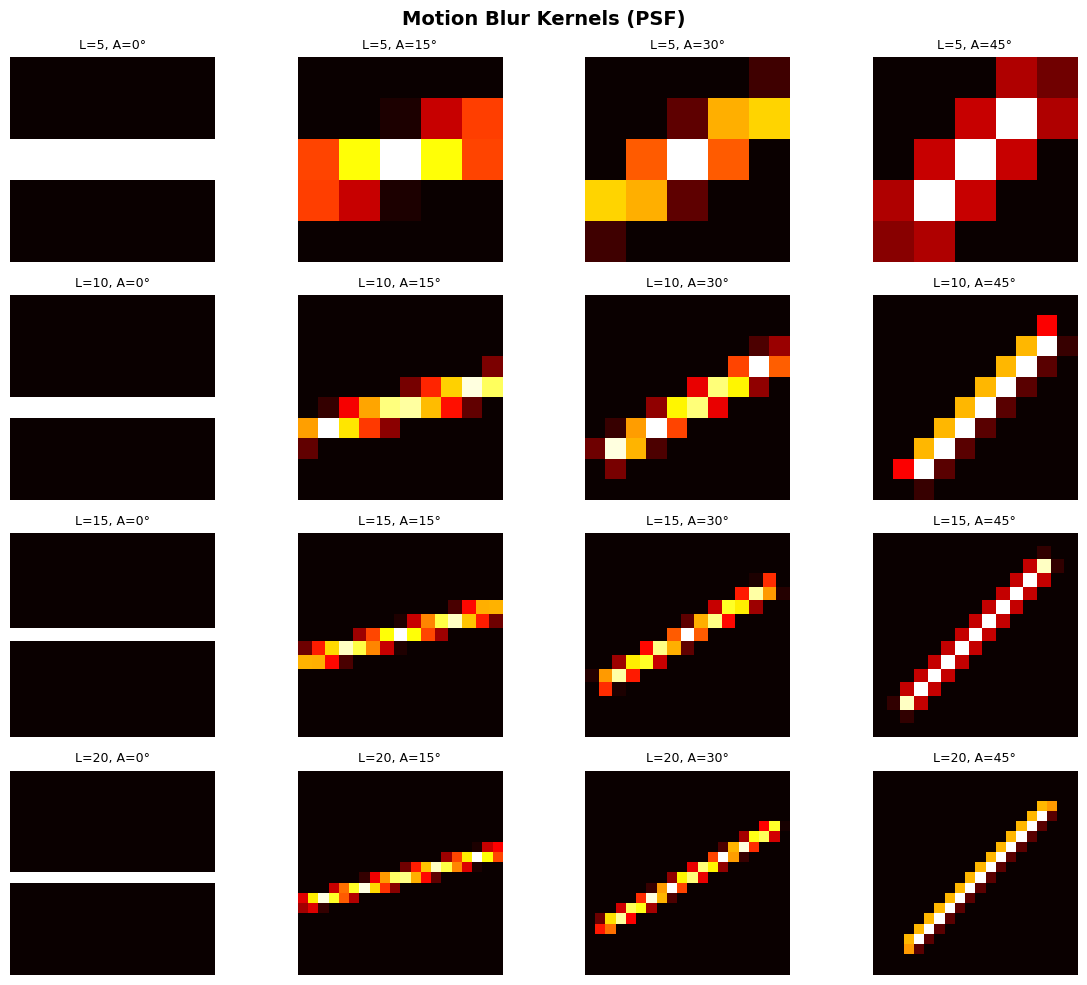

In [7]:
fig, axes = plt.subplots(len(BLUR_LENGTHS), len(BLUR_ANGLES),
                         figsize=(12, 10))
fig.suptitle('Motion Blur Kernels (PSF)', fontsize=14, fontweight='bold')

for i, length in enumerate(BLUR_LENGTHS):
    for j, angle in enumerate(BLUR_ANGLES):
        kernel = motion_blur_kernel(length=length, angle=angle)
        axes[i, j].imshow(kernel, cmap='hot', interpolation='nearest')
        axes[i, j].set_title(f'L={length}, A={angle}°', fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

### Process entire dataset

Apply all 16 blur configurations to each of the 50 original images.

In [8]:
image_files = sorted([
    f for f in os.listdir(INPUT_FOLDER)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
])

print(f'Found {len(image_files)} original images.')

for filename in image_files:
    image_path = os.path.join(INPUT_FOLDER, filename)
    image = cv2.imread(image_path)

    if image is None:
        print(f'Could not read: {filename}')
        continue

    processed = preprocess_image(image)
    base_name, _ = os.path.splitext(filename)

    for length in BLUR_LENGTHS:
        for angle in BLUR_ANGLES:
            kernel = motion_blur_kernel(length=length, angle=angle)
            blurred = apply_motion_blur(processed, kernel)

            blurred_name = f'{base_name}_L{length}_A{angle}.png'
            kernel_name  = f'kernel_L{length}_A{angle}.png'

            cv2.imwrite(os.path.join(BLURRED_FOLDER, blurred_name), blurred)
            save_kernel_visualization(
                kernel, os.path.join(KERNEL_FOLDER, kernel_name)
            )

print(f'Blur simulation complete. Generated {len(image_files) * len(BLUR_LENGTHS) * len(BLUR_ANGLES)} blurred images.')

Found 50 original images.
Blur simulation complete. Generated 800 blurred images.


### Sample: Original vs. Blurred

Visualize one image under all blur configurations.

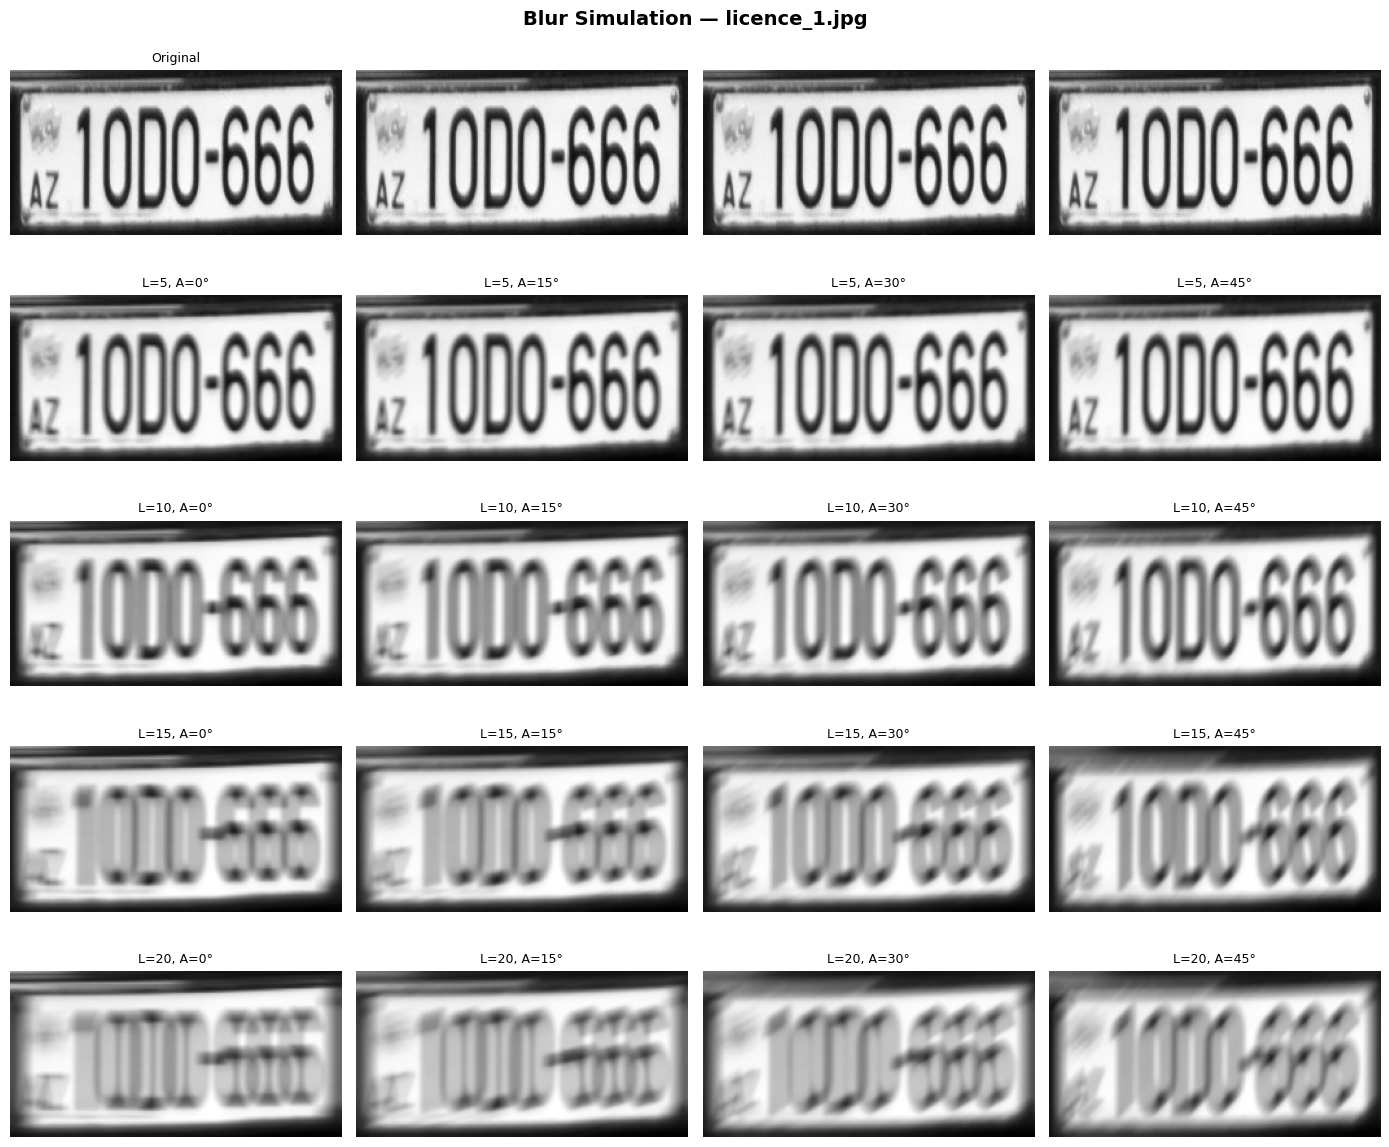

In [9]:
# Pick the first image for demonstration
sample_file = image_files[0]
sample_img = preprocess_image(cv2.imread(os.path.join(INPUT_FOLDER, sample_file)))

fig, axes = plt.subplots(len(BLUR_LENGTHS) + 1, len(BLUR_ANGLES),
                         figsize=(14, 12))

# Top row: original repeated
for j in range(len(BLUR_ANGLES)):
    axes[0, j].imshow(sample_img, cmap='gray')
    axes[0, j].set_title('Original' if j == 0 else '', fontsize=9)
    axes[0, j].axis('off')

for i, length in enumerate(BLUR_LENGTHS):
    for j, angle in enumerate(BLUR_ANGLES):
        kernel = motion_blur_kernel(length=length, angle=angle)
        blurred = apply_motion_blur(sample_img, kernel)
        axes[i + 1, j].imshow(blurred, cmap='gray')
        axes[i + 1, j].set_title(f'L={length}, A={angle}°', fontsize=9)
        axes[i + 1, j].axis('off')

fig.suptitle(f'Blur Simulation — {sample_file}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Image Restoration (Deblurring)

### Theory

In the **frequency domain**, convolution becomes multiplication:

$$G(u,v) = F(u,v) \\cdot H(u,v) + N(u,v)$$

#### Inverse Filtering
Direct division recovers the original spectrum:

$$\\hat{F}(u,v) = \\frac{G(u,v)}{H(u,v)}$$

This is extremely sensitive to noise — where $|H|$ is small, noise is amplified dramatically.

#### Wiener Filtering
Adds regularization to suppress noise amplification:

$$\\hat{F}(u,v) = \\frac{H^*(u,v)}{|H(u,v)|^2 + K} \\cdot G(u,v)$$

where $K$ is a regularization constant controlling the noise-suppression trade-off.

In [10]:
def psf_to_otf(psf, shape):
    """
    Convert Point Spread Function (PSF) to Optical Transfer Function (OTF).

    Pads the PSF to match the image size, circularly shifts it so the
    kernel center is at (0,0), then applies FFT.
    """
    psf_padded = np.zeros(shape, dtype=np.float32)
    kh, kw = psf.shape
    psf_padded[:kh, :kw] = psf

    # Circular shift so center of kernel is at (0,0)
    psf_padded = np.roll(psf_padded, -kh // 2, axis=0)
    psf_padded = np.roll(psf_padded, -kw // 2, axis=1)

    return np.fft.fft2(psf_padded)


def inverse_filter(blurred, kernel, eps=1e-3):
    """
    Restore image using inverse filtering in the frequency domain.
    eps prevents division by very small values.
    """
    blurred_float = blurred.astype(np.float32) / 255.0
    G = np.fft.fft2(blurred_float)
    H = psf_to_otf(kernel, blurred.shape)

    F_hat = G / (H + eps)
    restored = np.abs(np.fft.ifft2(F_hat))
    restored = np.clip(restored, 0, 1)

    return (restored * 255).astype(np.uint8)


def wiener_filter(blurred, kernel, K=0.01):
    """
    Restore image using Wiener filtering in the frequency domain.
    K controls the regularization / noise suppression strength.
    """
    blurred_float = blurred.astype(np.float32) / 255.0
    G = np.fft.fft2(blurred_float)
    H = psf_to_otf(kernel, blurred.shape)
    H_conj = np.conj(H)

    F_hat = (H_conj / (np.abs(H) ** 2 + K)) * G
    restored = np.abs(np.fft.ifft2(F_hat))
    restored = np.clip(restored, 0, 1)

    return (restored * 255).astype(np.uint8)

In [11]:
def parse_filename(filename):
    """
    Parse filenames like: licence_01_L15_A30.png
    Returns: base_name, length, angle
    """
    pattern = r"(.+)_L(\d+)_A(-?\d+)\.png"
    match = re.match(pattern, filename)
    if not match:
        return None, None, None
    return match.group(1), int(match.group(2)), int(match.group(3))

### Run deblurring on all blurred images

In [12]:
blurred_files = sorted([
    f for f in os.listdir(BLURRED_FOLDER)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
])

print(f'Found {len(blurred_files)} blurred images to restore.')

for filename in blurred_files:
    image_path = os.path.join(BLURRED_FOLDER, filename)
    blurred = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if blurred is None:
        continue

    base_name, length, angle = parse_filename(filename)
    if base_name is None:
        continue

    kernel = motion_blur_kernel(length=length, angle=angle)

    restored_inv    = inverse_filter(blurred, kernel, eps=1e-3)
    restored_wiener = wiener_filter(blurred, kernel, K=0.01)

    inv_name    = f'{base_name}_L{length}_A{angle}_inverse.png'
    wiener_name = f'{base_name}_L{length}_A{angle}_wiener.png'

    cv2.imwrite(os.path.join(RESTORED_INVERSE_FOLDER, inv_name), restored_inv)
    cv2.imwrite(os.path.join(RESTORED_WIENER_FOLDER, wiener_name), restored_wiener)

print('Deblurring complete.')

Found 800 blurred images to restore.
Deblurring complete.


### Sample: Inverse vs. Wiener Filtering

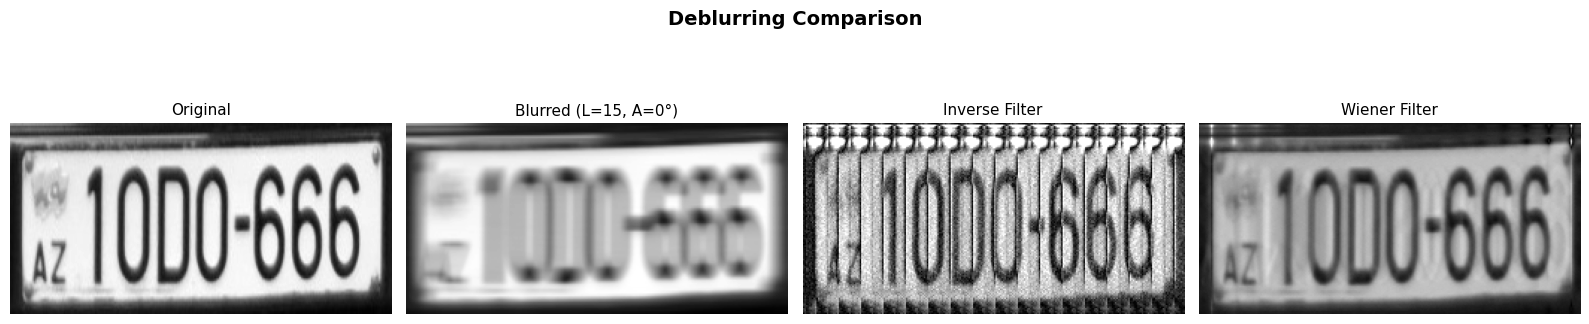

In [13]:
# Show one example at L=15, A=0
sample_base, _ = os.path.splitext(sample_file)
demo_L, demo_A = 15, 0

original = preprocess_image(cv2.imread(os.path.join(INPUT_FOLDER, sample_file)))
blurred  = cv2.imread(os.path.join(BLURRED_FOLDER, f'{sample_base}_L{demo_L}_A{demo_A}.png'),
                      cv2.IMREAD_GRAYSCALE)
inv_res  = cv2.imread(os.path.join(RESTORED_INVERSE_FOLDER,
                      f'{sample_base}_L{demo_L}_A{demo_A}_inverse.png'),
                      cv2.IMREAD_GRAYSCALE)
wien_res = cv2.imread(os.path.join(RESTORED_WIENER_FOLDER,
                      f'{sample_base}_L{demo_L}_A{demo_A}_wiener.png'),
                      cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', f'Blurred (L={demo_L}, A={demo_A}°)', 'Inverse Filter', 'Wiener Filter']
images = [original, blurred, inv_res, wien_res]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Deblurring Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Post-Processing Enhancement

After Wiener restoration, we apply a 3-stage enhancement pipeline:

1. **CLAHE** (Contrast-Limited Adaptive Histogram Equalization) improves local contrast
2. **Unsharp Masking** sharpens edges by amplifying high-frequency components
3. **Adaptive Binarization** converts to binary for character segmentation

In [14]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Improve local contrast using CLAHE."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)


def unsharp_mask(image, sigma=1.0, strength=1.5):
    """Sharpen image using unsharp masking."""
    blurred = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma)
    sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def adaptive_binarization(image):
    """Convert to binary for character visibility using adaptive thresholding."""
    return cv2.adaptiveThreshold(
        image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 21, 10
    )


def enhance_image(image):
    """Full enhancement pipeline: denoise → CLAHE → sharpen → binarize."""
    denoised   = cv2.GaussianBlur(image, (3, 3), 0)
    contrast   = apply_clahe(denoised, clip_limit=2.0, tile_grid_size=(8, 8))
    sharpened  = unsharp_mask(contrast, sigma=1.0, strength=1.2)
    binary     = adaptive_binarization(sharpened)
    return contrast, sharpened, binary

### Run enhancement on all Wiener-restored images

In [15]:
def add_label(image, text):
    """Add a title bar above the image for comparison panels."""
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    h, w = image.shape[:2]
    label_bar = np.ones((28, w, 3), dtype=np.uint8) * 255
    cv2.putText(label_bar, text, (8, 19),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1, cv2.LINE_AA)
    return np.vstack([label_bar, image])


wiener_files = sorted([
    f for f in os.listdir(RESTORED_WIENER_FOLDER)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
])

for filename in wiener_files:
    path = os.path.join(RESTORED_WIENER_FOLDER, filename)
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        continue

    contrast, sharpened, binary = enhance_image(image)

    enhanced_name   = filename.replace('_wiener', '_enhanced')
    binary_name     = filename.replace('_wiener', '_binary')
    comparison_name = filename.replace('_wiener', '_enhancement_panel')

    cv2.imwrite(os.path.join(ENHANCED_FOLDER, enhanced_name), sharpened)
    cv2.imwrite(os.path.join(THRESHOLDED_FOLDER, binary_name), binary)

    # Build comparison panel: Wiener | CLAHE | Sharpened | Thresholded
    panel = np.hstack([
        add_label(image, 'Wiener'),
        add_label(contrast, 'CLAHE'),
        add_label(sharpened, 'Sharpened'),
        add_label(binary, 'Thresholded')
    ])
    cv2.imwrite(os.path.join(ENHANCE_COMPARISON_FOLDER, comparison_name), panel)

print(f'Enhancement complete. Processed {len(wiener_files)} images.')

Enhancement complete. Processed 800 images.


### Sample: Enhancement Pipeline

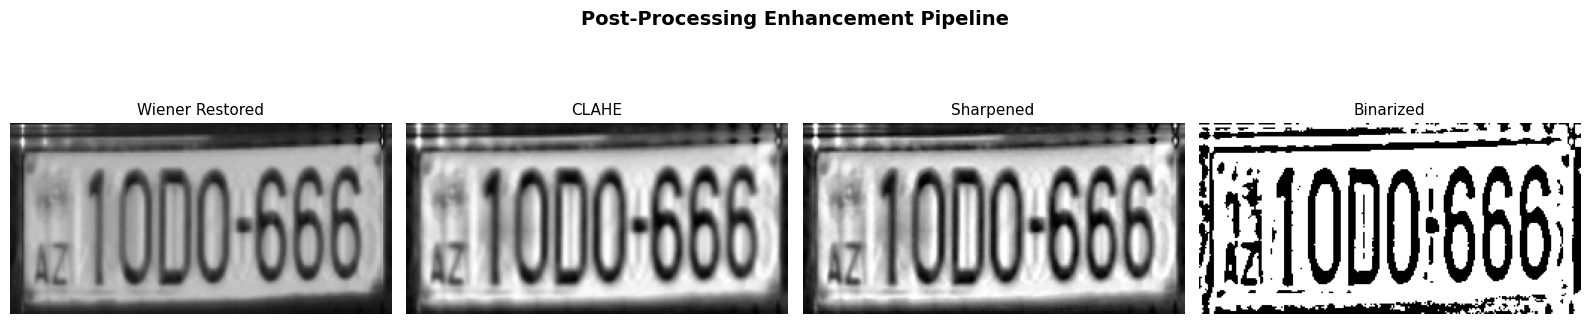

In [16]:
# Show enhancement stages for the demo image
wien_demo = cv2.imread(
    os.path.join(RESTORED_WIENER_FOLDER, f'{sample_base}_L{demo_L}_A{demo_A}_wiener.png'),
    cv2.IMREAD_GRAYSCALE
)
contrast, sharpened, binary = enhance_image(wien_demo)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
stages = [
    (wien_demo,  'Wiener Restored'),
    (contrast,   'CLAHE'),
    (sharpened,  'Sharpened'),
    (binary,     'Binarized')
]

for ax, (img, title) in zip(axes, stages):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Post-Processing Enhancement Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Evaluation & Metrics

We quantitatively assess restoration quality using two standard metrics:

- **PSNR** (Peak Signal-to-Noise Ratio): measures pixel-level fidelity (higher = better)
- **SSIM** (Structural Similarity Index): measures perceptual similarity (closer to 1 = better)

Both metrics compare restored images against the original ground truth.

In [17]:
def compute_metrics(reference, test):
    """Compute PSNR and SSIM between reference and test image."""
    psnr = peak_signal_noise_ratio(reference, test, data_range=255)
    ssim = structural_similarity(reference, test, data_range=255)
    return psnr, ssim


def build_comparison_panel(original, blurred, inverse, wiener):
    """Create a horizontal panel: Original | Blurred | Inverse | Wiener."""
    return np.hstack([
        add_label(original, 'Original'),
        add_label(blurred, 'Blurred'),
        add_label(inverse, 'Inverse'),
        add_label(wiener, 'Wiener')
    ])

### Compute metrics for all images

In [18]:
rows = []

for blurred_filename in sorted(os.listdir(BLURRED_FOLDER)):
    if not blurred_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        continue

    base_name, length, angle = parse_filename(blurred_filename)
    if base_name is None:
        continue

    # Find original
    original_path = None
    for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
        candidate = os.path.join(INPUT_FOLDER, base_name + ext)
        if os.path.exists(candidate):
            original_path = candidate
            break
    if original_path is None:
        continue

    inv_name    = f'{base_name}_L{length}_A{angle}_inverse.png'
    wiener_name = f'{base_name}_L{length}_A{angle}_wiener.png'

    inverse_path = os.path.join(RESTORED_INVERSE_FOLDER, inv_name)
    wiener_path  = os.path.join(RESTORED_WIENER_FOLDER, wiener_name)

    if not os.path.exists(inverse_path) or not os.path.exists(wiener_path):
        continue

    original_bgr = cv2.imread(original_path)
    blurred_img  = cv2.imread(os.path.join(BLURRED_FOLDER, blurred_filename), cv2.IMREAD_GRAYSCALE)
    inverse_img  = cv2.imread(inverse_path, cv2.IMREAD_GRAYSCALE)
    wiener_img   = cv2.imread(wiener_path, cv2.IMREAD_GRAYSCALE)

    if any(x is None for x in [original_bgr, blurred_img, inverse_img, wiener_img]):
        continue

    original = preprocess_image(original_bgr)

    psnr_b, ssim_b = compute_metrics(original, blurred_img)
    psnr_i, ssim_i = compute_metrics(original, inverse_img)
    psnr_w, ssim_w = compute_metrics(original, wiener_img)

    # Save comparison panel
    panel = build_comparison_panel(original, blurred_img, inverse_img, wiener_img)
    comp_name = f'{base_name}_L{length}_A{angle}_comparison.png'
    cv2.imwrite(os.path.join(COMPARISON_FOLDER, comp_name), panel)

    rows.append({
        'image': base_name, 'blur_length': length, 'angle': angle,
        'psnr_blurred': round(psnr_b, 3), 'ssim_blurred': round(ssim_b, 4),
        'psnr_inverse': round(psnr_i, 3), 'ssim_inverse': round(ssim_i, 4),
        'psnr_wiener':  round(psnr_w, 3), 'ssim_wiener':  round(ssim_w, 4),
    })

df = pd.DataFrame(rows).sort_values(by=['image', 'blur_length', 'angle']).reset_index(drop=True)

# Save CSVs
df.to_csv(os.path.join(METRICS_FOLDER, 'evaluation_results.csv'), index=False)

summary = pd.DataFrame({
    'mean_psnr_blurred':  [df['psnr_blurred'].mean()],
    'mean_ssim_blurred':  [df['ssim_blurred'].mean()],
    'mean_psnr_inverse':  [df['psnr_inverse'].mean()],
    'mean_ssim_inverse':  [df['ssim_inverse'].mean()],
    'mean_psnr_wiener':   [df['psnr_wiener'].mean()],
    'mean_ssim_wiener':   [df['ssim_wiener'].mean()],
})
summary.to_csv(os.path.join(METRICS_FOLDER, 'evaluation_summary.csv'), index=False)

print(f'Evaluation complete. {len(df)} image-blur combinations assessed.')
print()
print(summary.T.rename(columns={0: 'Value'}))

Evaluation complete. 800 image-blur combinations assessed.

                       Value
mean_psnr_blurred  24.648546
mean_ssim_blurred   0.739242
mean_psnr_inverse   9.693264
mean_ssim_inverse   0.120797
mean_psnr_wiener   22.214802
mean_ssim_wiener    0.730094


### Detailed results (first 20 rows)

In [19]:
df.head(20)

,image,blur_length,angle,psnr_blurred,ssim_blurred,psnr_inverse,ssim_inverse,psnr_wiener,ssim_wiener
0,licence_1,5,0,26.099,0.9277,16.752,0.5614,20.596,0.7938
1,licence_1,5,15,26.369,0.9309,11.129,0.2096,20.565,0.7963
2,licence_1,5,30,27.035,0.9366,9.952,0.1582,20.500,0.7939
3,licence_1,5,45,28.505,0.9482,13.825,0.3935,20.403,0.7896
4,licence_1,10,0,18.990,0.6977,13.437,0.4364,21.730,0.8215
5,licence_1,10,15,19.224,0.7071,15.248,0.4766,22.869,0.8366
6,licence_1,10,30,19.785,0.7240,9.798,0.1477,23.233,0.8207
7,licence_1,10,45,21.200,0.7701,14.630,0.4302,25.747,0.8654
8,licence_1,15,0,16.674,0.5486,11.708,0.3445,19.761,0.7124
9,licence_1,15,15,16.745,0.5444,8.355,0.0816,19.383,0.6776


## 7. Visualization & Analysis

Let's visualize the metrics to understand how blur severity affects restoration quality.

### 7.1 Mean PSNR & SSIM and Blurred vs. Inverse vs. Wiener

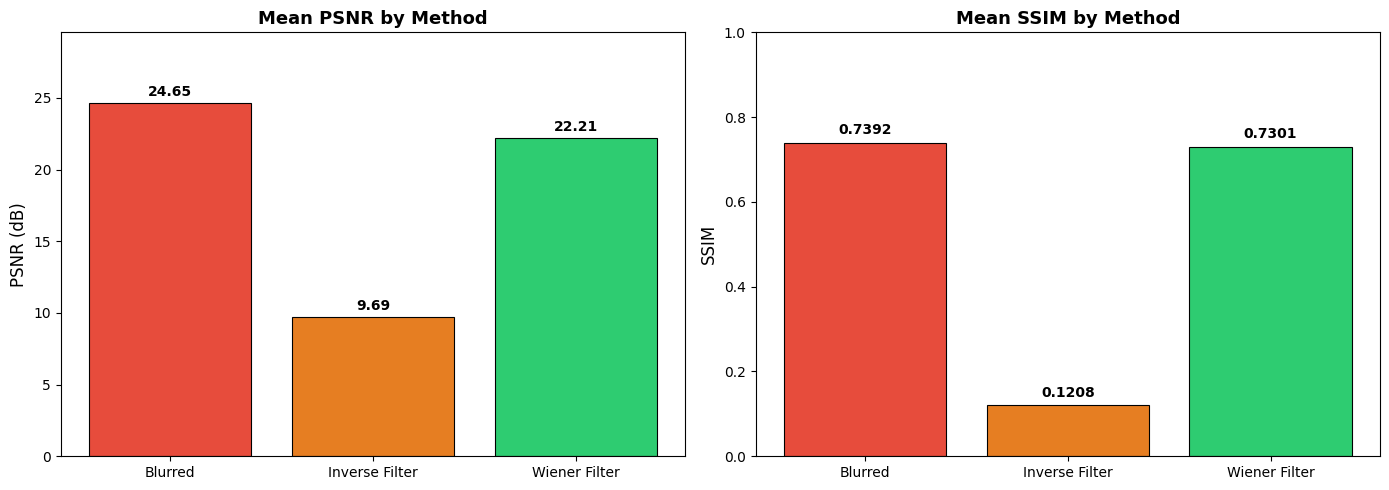

In [20]:
methods = ['Blurred', 'Inverse Filter', 'Wiener Filter']
mean_psnr = [df['psnr_blurred'].mean(), df['psnr_inverse'].mean(), df['psnr_wiener'].mean()]
mean_ssim = [df['ssim_blurred'].mean(), df['ssim_inverse'].mean(), df['ssim_wiener'].mean()]

colors = ['#e74c3c', '#e67e22', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(methods, mean_psnr, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('Mean PSNR by Method', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(mean_psnr) * 1.2)
for bar, val in zip(bars1, mean_psnr):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}', ha='center', fontweight='bold')

bars2 = ax2.bar(methods, mean_ssim, color=colors, edgecolor='black', linewidth=0.8)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('Mean SSIM by Method', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1.0)
for bar, val in zip(bars2, mean_ssim):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2 PSNR vs. Blur Kernel Length

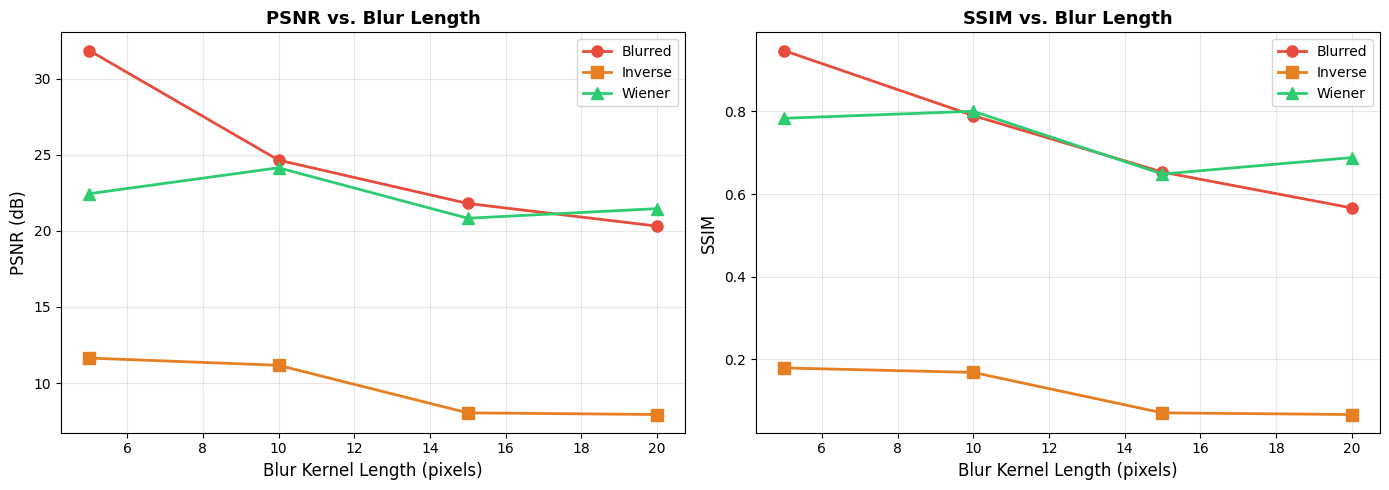

In [21]:
grouped = df.groupby('blur_length').agg({
    'psnr_blurred': 'mean',
    'psnr_inverse': 'mean',
    'psnr_wiener': 'mean',
    'ssim_blurred': 'mean',
    'ssim_inverse': 'mean',
    'ssim_wiener': 'mean',
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(grouped['blur_length'], grouped['psnr_blurred'], 'o-',
         color='#e74c3c', label='Blurred', linewidth=2, markersize=8)
ax1.plot(grouped['blur_length'], grouped['psnr_inverse'], 's-',
         color='#e67e22', label='Inverse', linewidth=2, markersize=8)
ax1.plot(grouped['blur_length'], grouped['psnr_wiener'], '^-',
         color='#2ecc71', label='Wiener', linewidth=2, markersize=8)
ax1.set_xlabel('Blur Kernel Length (pixels)', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('PSNR vs. Blur Length', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(grouped['blur_length'], grouped['ssim_blurred'], 'o-',
         color='#e74c3c', label='Blurred', linewidth=2, markersize=8)
ax2.plot(grouped['blur_length'], grouped['ssim_inverse'], 's-',
         color='#e67e22', label='Inverse', linewidth=2, markersize=8)
ax2.plot(grouped['blur_length'], grouped['ssim_wiener'], '^-',
         color='#2ecc71', label='Wiener', linewidth=2, markersize=8)
ax2.set_xlabel('Blur Kernel Length (pixels)', fontsize=12)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('SSIM vs. Blur Length', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 PSNR vs. Blur Angle

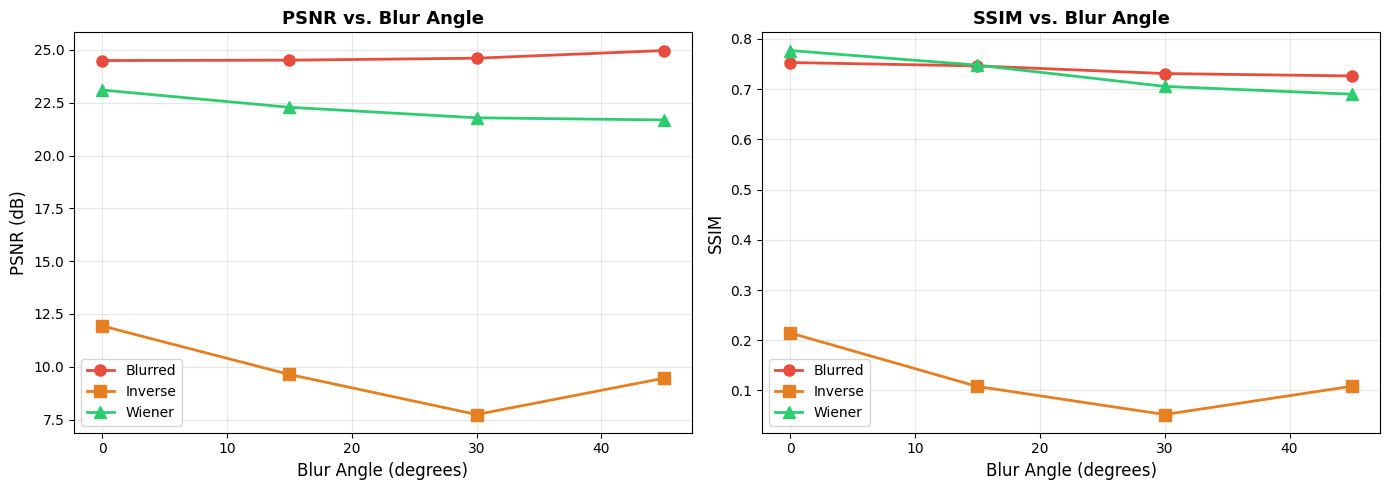

In [22]:
grouped_angle = df.groupby('angle').agg({
    'psnr_blurred': 'mean',
    'psnr_inverse': 'mean',
    'psnr_wiener': 'mean',
    'ssim_blurred': 'mean',
    'ssim_inverse': 'mean',
    'ssim_wiener': 'mean',
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(grouped_angle['angle'], grouped_angle['psnr_blurred'], 'o-',
         color='#e74c3c', label='Blurred', linewidth=2, markersize=8)
ax1.plot(grouped_angle['angle'], grouped_angle['psnr_inverse'], 's-',
         color='#e67e22', label='Inverse', linewidth=2, markersize=8)
ax1.plot(grouped_angle['angle'], grouped_angle['psnr_wiener'], '^-',
         color='#2ecc71', label='Wiener', linewidth=2, markersize=8)
ax1.set_xlabel('Blur Angle (degrees)', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('PSNR vs. Blur Angle', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(grouped_angle['angle'], grouped_angle['ssim_blurred'], 'o-',
         color='#e74c3c', label='Blurred', linewidth=2, markersize=8)
ax2.plot(grouped_angle['angle'], grouped_angle['ssim_inverse'], 's-',
         color='#e67e22', label='Inverse', linewidth=2, markersize=8)
ax2.plot(grouped_angle['angle'], grouped_angle['ssim_wiener'], '^-',
         color='#2ecc71', label='Wiener', linewidth=2, markersize=8)
ax2.set_xlabel('Blur Angle (degrees)', fontsize=12)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('SSIM vs. Blur Angle', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Heatmap: Wiener PSNR by Length × Angle

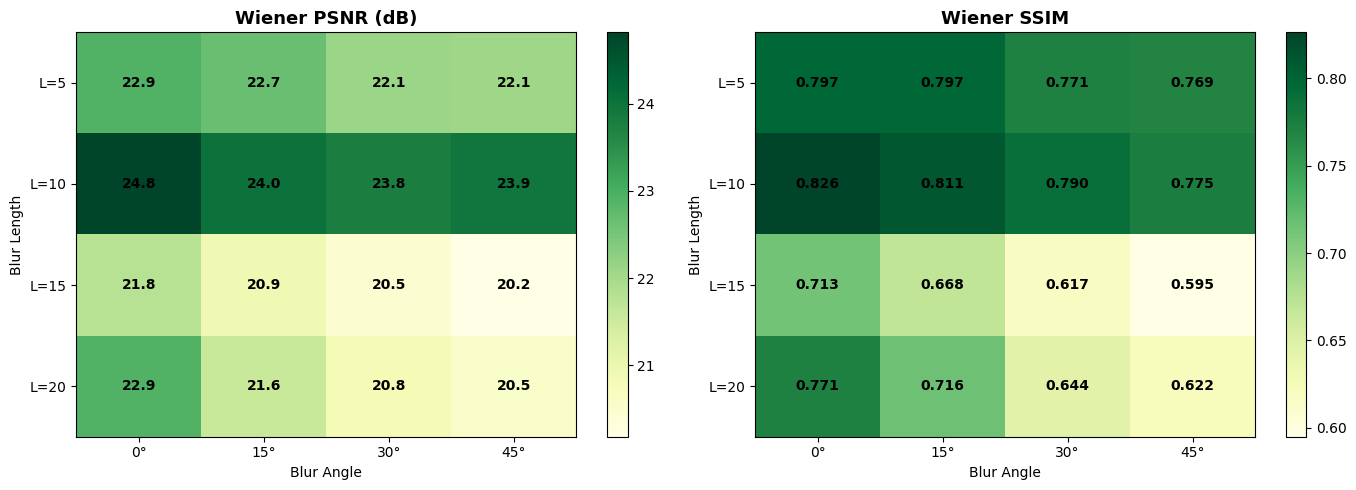

In [23]:
pivot_psnr = df.groupby(['blur_length', 'angle'])['psnr_wiener'].mean().unstack()
pivot_ssim = df.groupby(['blur_length', 'angle'])['ssim_wiener'].mean().unstack()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(pivot_psnr.values, cmap='YlGn', aspect='auto')
ax1.set_xticks(range(len(pivot_psnr.columns)))
ax1.set_xticklabels([f'{a}°' for a in pivot_psnr.columns])
ax1.set_yticks(range(len(pivot_psnr.index)))
ax1.set_yticklabels([f'L={l}' for l in pivot_psnr.index])
ax1.set_xlabel('Blur Angle')
ax1.set_ylabel('Blur Length')
ax1.set_title('Wiener PSNR (dB)', fontsize=13, fontweight='bold')
for i in range(len(pivot_psnr.index)):
    for j in range(len(pivot_psnr.columns)):
        ax1.text(j, i, f'{pivot_psnr.values[i,j]:.1f}',
                 ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(pivot_ssim.values, cmap='YlGn', aspect='auto')
ax2.set_xticks(range(len(pivot_ssim.columns)))
ax2.set_xticklabels([f'{a}°' for a in pivot_ssim.columns])
ax2.set_yticks(range(len(pivot_ssim.index)))
ax2.set_yticklabels([f'L={l}' for l in pivot_ssim.index])
ax2.set_xlabel('Blur Angle')
ax2.set_ylabel('Blur Length')
ax2.set_title('Wiener SSIM', fontsize=13, fontweight='bold')
for i in range(len(pivot_ssim.index)):
    for j in range(len(pivot_ssim.columns)):
        ax2.text(j, i, f'{pivot_ssim.values[i,j]:.3f}',
                 ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

### 7.5 Multi-Image Comparison Grid

Show 5 sample images at a moderate blur (L=15, A=0) across all pipeline stages.

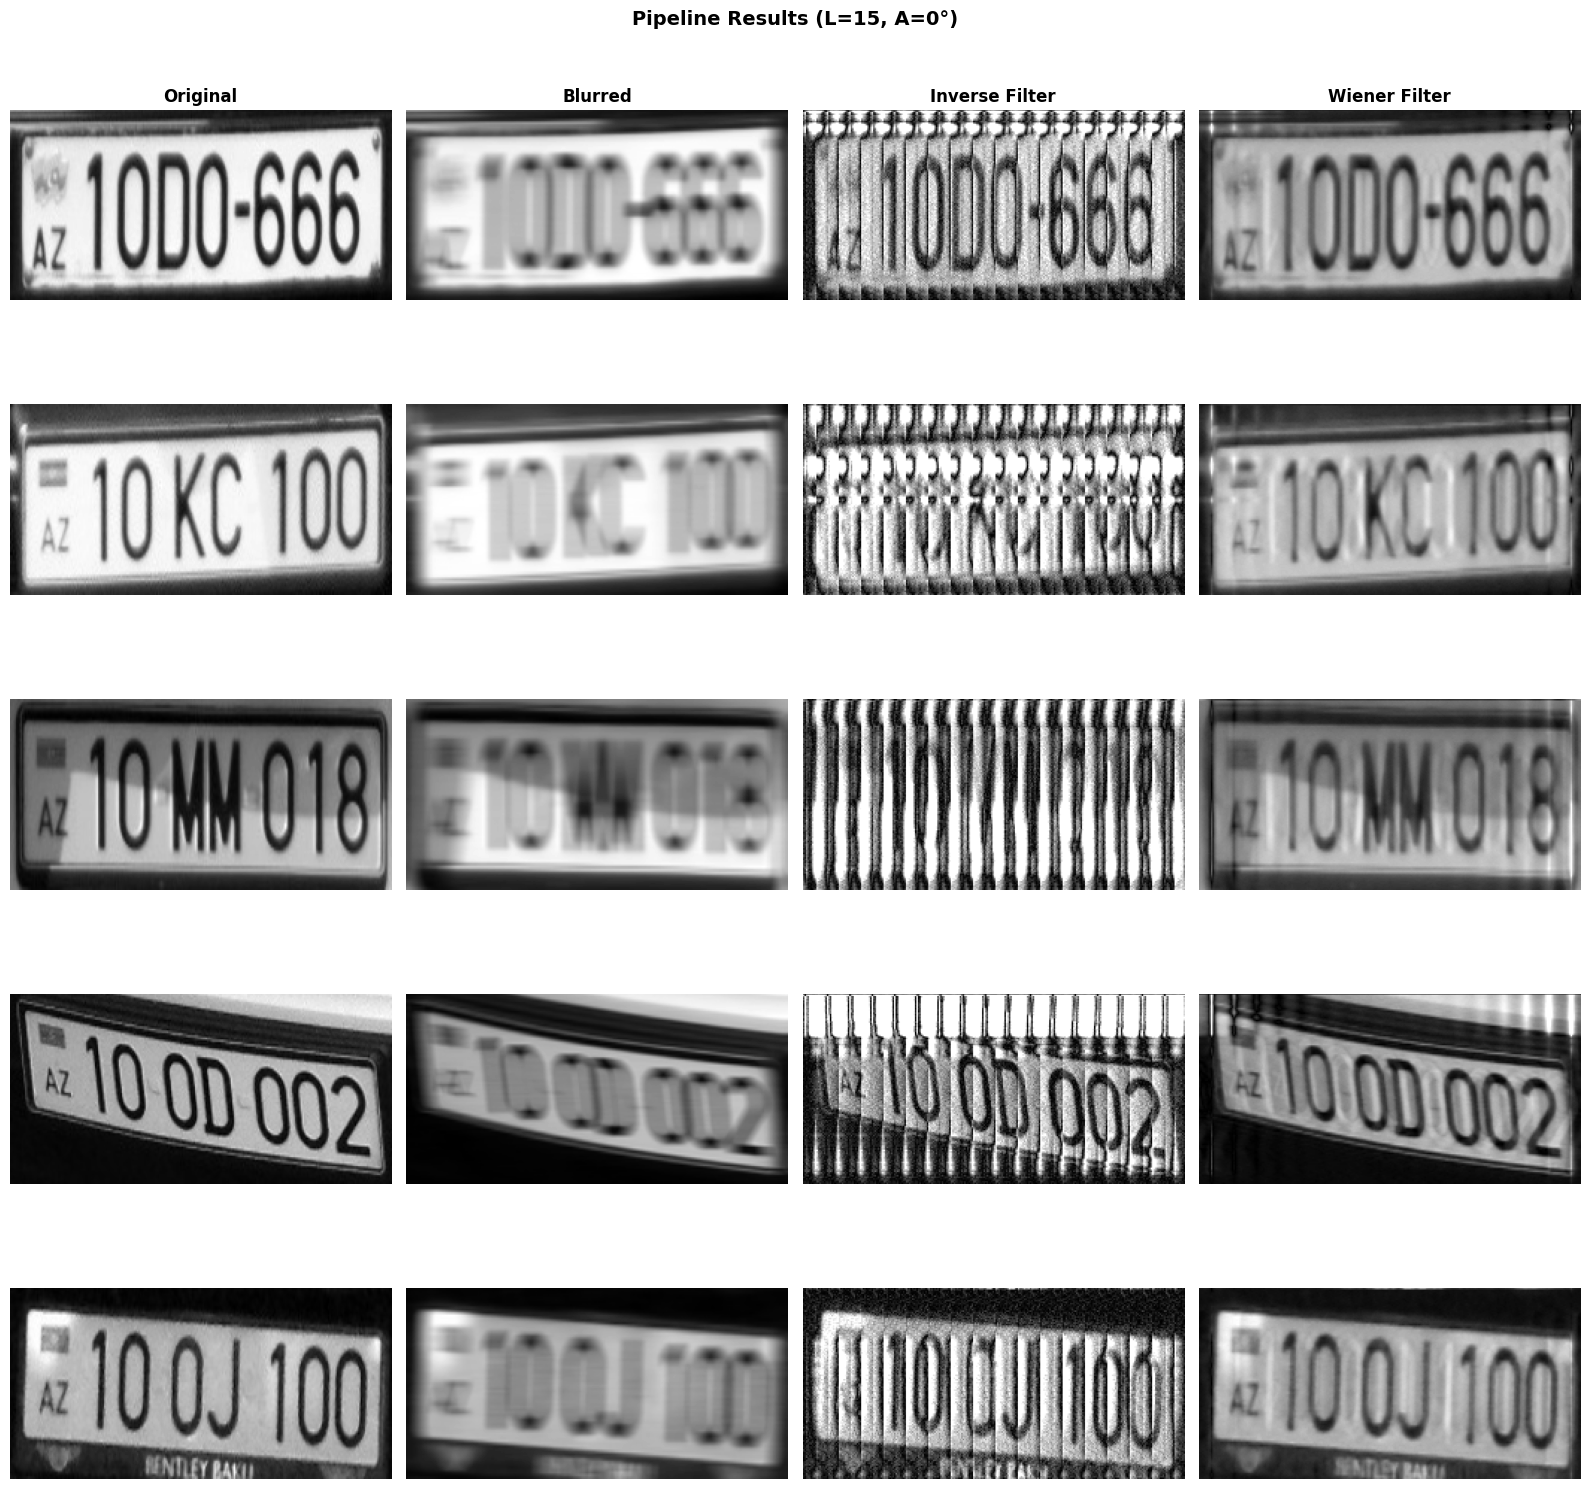

In [ ]:
sample_images = image_files[:5]  # First 5 images
demo_params = (15, 0)

fig, axes = plt.subplots(5, 4, figsize=(16, 16))
col_titles = ['Original', 'Blurred', 'Inverse Filter', 'Wiener Filter']

for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12, fontweight='bold')

for i, fname in enumerate(sample_images):
    bname, _ = os.path.splitext(fname)
    L, A = demo_params

    orig = preprocess_image(cv2.imread(os.path.join(INPUT_FOLDER, fname)))
    blur = cv2.imread(os.path.join(BLURRED_FOLDER, f'{bname}_L{L}_A{A}.png'),
                      cv2.IMREAD_GRAYSCALE)
    inv  = cv2.imread(os.path.join(RESTORED_INVERSE_FOLDER, f'{bname}_L{L}_A{A}_inverse.png'),
                      cv2.IMREAD_GRAYSCALE)
    wien = cv2.imread(os.path.join(RESTORED_WIENER_FOLDER, f'{bname}_L{L}_A{A}_wiener.png'),
                      cv2.IMREAD_GRAYSCALE)

    for j, img in enumerate([orig, blur, inv, wien]):
        if img is not None:
            axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(bname, fontsize=9, rotation=0, labelpad=70)

plt.suptitle(f'Pipeline Results (L={L}, A={A}°)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Conclusion

### Key Findings

| Observation | Detail |
|---|---|
| **Wiener ≫ Inverse** | Wiener filtering consistently outperforms inverse filtering across all blur configurations |
| **Inverse filtering fails** | Mean PSNR drops to ~9.7 dB due to severe noise amplification where $\\|H(u,v)\\| \approx 0$ |
| **Wiener is robust** | Maintains SSIM ~0.73 even under heavy blur (L=20), thanks to regularization parameter $K$ |
| **Blur length matters more** | Increasing kernel length degrades quality more than changing angle |
| **Enhancement helps** | CLAHE + sharpening improves visual readability of restored plates |

### Limitations

- **Known PSF assumed**: Real-world blur kernel is unknown and must be estimated (blind deconvolution)
- **No noise model**: Synthetic blur is noise-free; real images have sensor noise
- **Fixed K parameter**: Wiener K could be optimized per-image for better results

### Course Concepts Applied

- Spatial filtering (convolution)
- Frequency domain analysis (DFT/FFT)
- Image degradation model (PSF, OTF)
- Image restoration (inverse & Wiener filtering)
- Histogram equalization (CLAHE)
- Edge enhancement (unsharp masking)
- Binarization (adaptive thresholding)
- Quality metrics (PSNR, SSIM)

---

*Group BufferOverflow - Methqphore*